In [1]:
import torch
import torch.nn.functional as F
import requests
import os
import random
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import tqdm
from tqdm.auto import tqdm
import plt

/home/xerneas/jupyter-env/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = "input.txt"
if not os.path.exists(path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    resp = requests.get(url, stream=True)
    total = int(resp.headers.get("Content-Length", 0))
    with open(path, "wb") as f:
        bar = tqdm(total=total, unit="B", unit_scale=True, desc="input.txt")
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
        bar.close()

with open(path) as f:
    text = f.read()

print(len(text))
print(text[:500])

1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
if (device := torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")):
    print(f"Using device: {device}")

block_size = 8
epochs = 400
lr = 0.001
embd = 32
head = 100
batch=8192

Using device: cuda


In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
print(chars)
def stoi(x):
    return chars.index(x) if isinstance(x, str) else chars[x]
_stoi = {c: i for i, c in enumerate(chars)}
def itos(x):
    return _stoi[x] if isinstance(x, str) else chars[x]

print("itos:", itos(1), itos(2), itos(3), itos(0), "\n")
print("stoi:", stoi('.'), stoi('a'), stoi('b'), stoi('c'), "/n")

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
itos:   ! $ 
 

stoi: 8 39 40 41 /n


In [5]:
def build_dataset(data):
    X, Y = [], []
    for i in range(len(data) - block_size):
        X.append(data[i : i + block_size])
        Y.append(data[i+1 : i + block_size + 1])
    X = torch.stack(X)
    Y = torch.stack(Y)
    return X, Y

In [6]:
data = torch.tensor([stoi(c) for c in text])
X, Y = build_dataset(data)
n = X.shape[0]
Xtr, Ytr = X[:int(n*0.9)], Y[:int(n*0.9)]
Xdev, Ydev = X[int(n*0.9):], Y[int(n*0.9):]
Xtr, Ytr = [x.to(device) for x in (Xtr, Ytr)]
Xdev, Ydev = [x.to(device) for x in (Xdev, Ydev)]
print(X.shape, Y.shape)
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)

torch.Size([1115386, 8]) torch.Size([1115386, 8])
torch.Size([1003847, 8]) torch.Size([1003847, 8])
torch.Size([111539, 8]) torch.Size([111539, 8])


In [7]:
trainds = torch.utils.data.TensorDataset(Xtr.cpu(), Ytr.cpu())
traindl = DataLoader(
    dataset=trainds,
    batch_size=batch,
    pin_memory=False,
    shuffle=True,
    num_workers=16,
    prefetch_factor=16
)

In [8]:
class Head(nn.Module):
    def __init__(self, head_size, embd):
        super().__init__()
        self.key = nn.Linear(embd, head_size, bias=False)
        self.query = nn.Linear(embd, head_size, bias=False)
        self.value = nn.Linear(embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5 #BTC @ BCT => BTT
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        out = wei @ v
        return out
        

In [9]:
class multihead(nn.Module):
    def __init__(self, num_heads, head_size, embd):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, embd) for _ in range(num_heads)])
        self.proj = nn.Linear(embd, embd)

    def forward(self, x):
        stack = torch.cat([h(x) for h in self.heads], dim=-1)
        stack = self.proj(stack)
        return stack

In [10]:
class feedForward(nn.Module):
    def __init__(self, embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embd, embd),
            nn.ReLU(),
            nn.Linear(embd, embd)
        )
    def forward(self, x):
        return self.net(x)

In [11]:
class attenB(nn.Module):
    def __init__(self, embd, nhead):
        super().__init__()
        self.ffw = feedForward(embd)
        self.sa = multihead(nhead, embd//nhead, embd)
    def forward(self, x):
        x = x + self.sa(x)
        x = x + self.ffw(x)
        return x

In [12]:
class LM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, embd)
        self.position_embedding = nn.Embedding(block_size, embd)
        self.atten = nn.Sequential(
            attenB(embd, 4),
            attenB(embd, 4),
            attenB(embd, 4),
        )
        self.lm = nn.Linear(embd, vocab_size)
        self.ffw = feedForward(embd)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.atten(x)
        return self.lm(x)
    

In [13]:
model = LM().to(device)
# model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.99995)

In [14]:
model.train()
pbar = tqdm(range(epochs), desc="train")
t_loss = []
for e in pbar:
    e_loss = []
    for Xb, Yb in traindl:
        Xb, Yb = Xb.to(device), Yb.to(device)
        logits = model(Xb)
        loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
        e_loss.append(loss.item())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()
    t_loss.append(sum(e_loss) / len(e_loss))
    pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
    # if e % 10 == 0:
    #     print(e, loss.item(), scheduler.get_last_lr()[0])

train:  72%|███████▏  | 287/400 [11:47<04:38,  2.46s/it, loss=1.7757, lr=1.71e-04]


KeyboardInterrupt: 

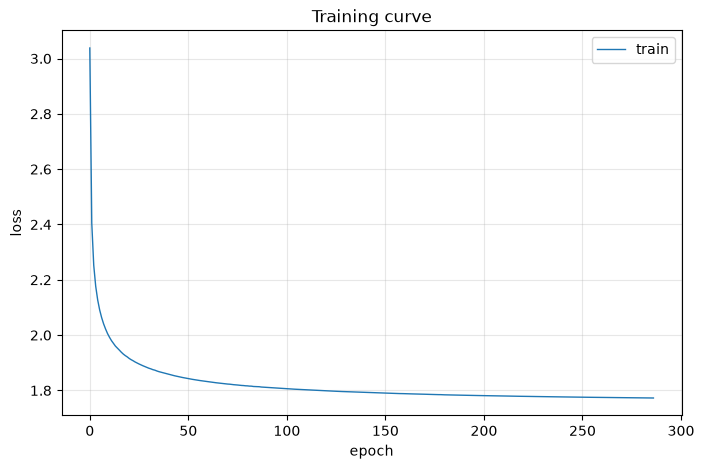

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(t_loss)), t_loss, label='train', linewidth=1)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
model.eval()
with torch.no_grad():
    ix = torch.randint(0, Xtr.shape[0], (Xtr.shape[0],), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]
    logits = model(Xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
    print("train loss:", loss.item())

    ix = torch.randint(0, Xdev.shape[0], (Xdev.shape[0],), device=device)
    Xb, Yb = Xdev[ix], Ydev[ix]
    logits = model(Xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
    print("dev loss:", loss.item())


train loss: 1.7725896835327148
dev loss: 1.9812277555465698


In [17]:
model.eval()
for i in range(10):
    out = []
    context = [0] * block_size
    for _ in range(50):
        logits = model(torch.tensor([context], device=device))
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos(ix))
    print(''.join(out))

NORTHUMBERLAND:
Nay.' both place.
Fayer?

SICINIUS
COMINIUS:
Farew they murdish not a peoplest her th
WESTER:
Which, hO weack'd yet I most off; but you 
KING RICHARD IV:
Shall of
For every?

ROMEO:
One p
First you we mother.

COMINIUS:
Ay, made naments n
QUEEN ELIZABETH:
And it
Were verce our wonder's th
KING HENRY BOLINGBROKE:
Eithed.
As never;
Poge, ma
SLY:
I power
Did
In we will all I would the to tha
FLORIZELTHA:
Now such you mabout rody,
Madamsira, 
CORIOLANUS:
What a Making:
The maditily virmonge a
